<a href="https://colab.research.google.com/github/shriver42/ESAA/blob/%ED%95%84%EC%82%AC-%EA%B3%BC%EC%A0%9C/1118_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###04. 위성 이미지 분류

In [ ]:
#텐서플로 데이터셋 로드
import tensorflow as tf
import numpy as np
import json
import matplotlib.pylab as plt

# Tensorflow Datasets 활용
import tensorflow_datasets as tfds

In [ ]:
# EuroSAT 위성 사진 데이터셋 로드

DATA_DIR = 'datasets/'

(train_ds, valid_ds), info = tfds.load('eurosat/rgb', split=['train[:80%]', 'train[80%:]'],
                                       shuffle_files=True,
                                       as_supervised=True,
                                       with_info=True,
                                       data_dir=DATA_DIR)
print(train_ds)
print(valid_ds)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

In [ ]:
# 메타 데이터 확인
print(info)

tfds.core.DatasetInfo(
    name='eurosat',
    full_name='eurosat/rgb/2.0.0',
    description="""
    EuroSAT dataset is based on Sentinel-2 satellite images covering 13 spectral
    bands and consisting of 10 classes with 27000 labeled and
    geo-referenced samples.
    
    Two datasets are offered:
    - rgb: Contains only the optical R, G, B frequency bands encoded as JPEG image.
    - all: Contains all 13 bands in the original value range (float32).
    
    URL: https://github.com/phelber/eurosat
    """,
    config_description="""
    Sentinel-2 RGB channels
    """,
    homepage='https://github.com/phelber/eurosat',
    data_dir=PosixGPath('/tmp/tmpkwjavom4tfds'),
    file_format=tfrecord,
    download_size=89.91 MiB,
    dataset_size=89.50 MiB,
    features=FeaturesDict({
        'filename': Text(shape=(), dtype=string),
        'image': Image(shape=(64, 64, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('ima

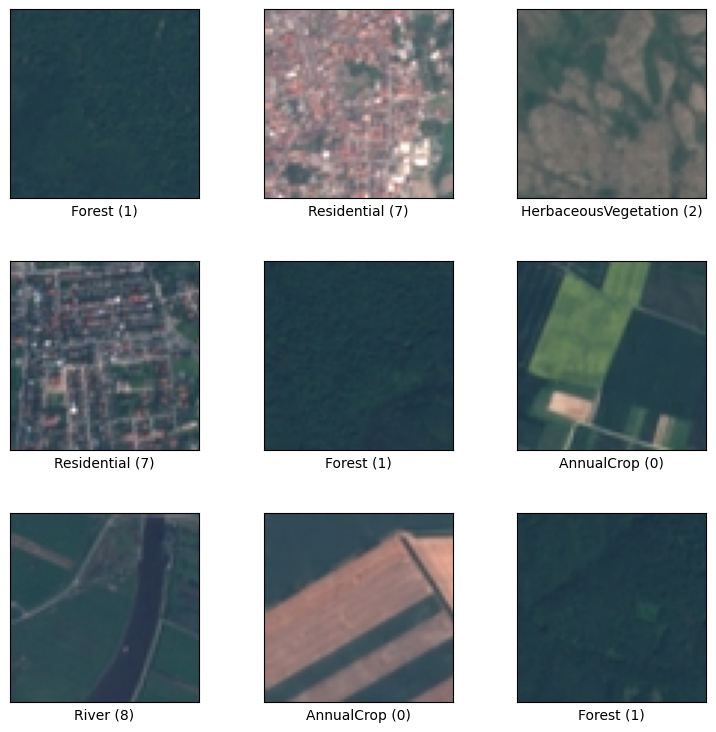

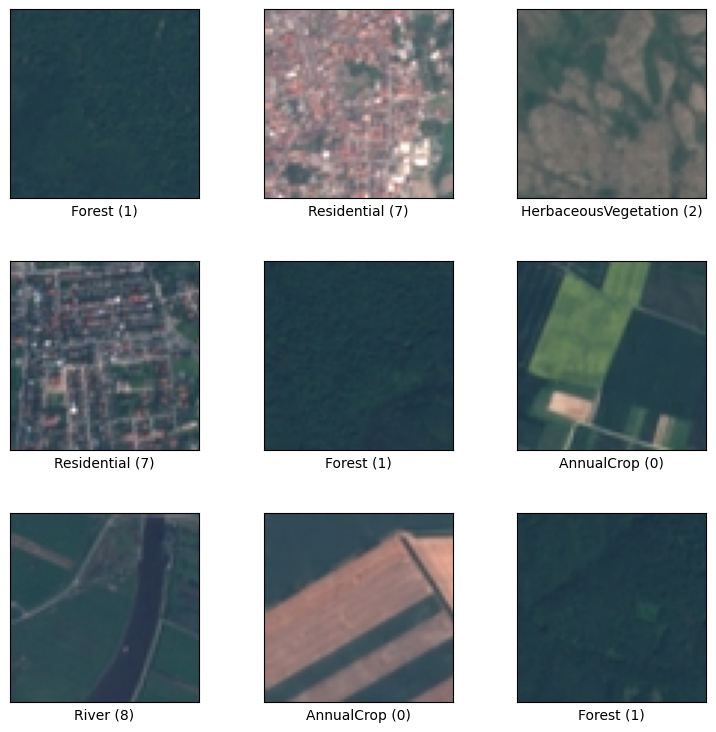

In [ ]:
# 샘플 이미지를 메타 정보인 분류 레이블과 함께 화면에 출력 'show_examples' 함수 사용

# 데이터 확인
tfds.show_examples(train_ds, info)

,image,label
0,,5 (Pasture)
1,,7 (Residential)
2,,0 (AnnualCrop)
3,,1 (Forest)
4,,0 (AnnualCrop)
5,,2 (HerbaceousVegetation)
6,,9 (SeaLake)
7,,8 (River)
8,,2 (HerbaceousVegetation)
9,,9 (SeaLake)

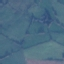
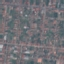
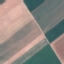
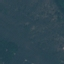
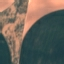
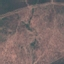
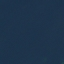
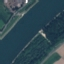
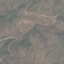
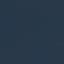

In [ ]:
# as_dataframe 함수 사용하여 샘플 출력
tfds.as_dataframe(valid_ds.take(10), info)

In [ ]:
# 목표 클래스의 개수
NUM_CLASSES = info.features["label"].num_classes
print(NUM_CLASSES)

10


-> 토지 이용 분류에 해당하는 정답 클래스 개수: 10개

In [ ]:
# 숫자 레이블을 활용해 문자열 메타 데이터로 변환
print(info.features["label"].int2str(6))

PermanentCrop


**데이터 전처리**
- cast 함수: 자료형 -> float32
  - 입력이미지는 0~255 범위의 픽셀 값을 갖기 때문에 255로 나누어 정규화
- map 함수: 사용자 정의 함수를 매핑하여 텐서플로 데이터셋에 적용하는 메소드
  - num_parallel_calls 옵션을 오툐튠으로 지정하면 텐서플로 병렬연산 처리를 자동으로 최적화
- shuffle() : 순서를 랜덤하게 섞어줌. -> 모델의 일반화된 성능을 높이기 위해 훈련 데이터셋에서 미니배치를 생성할 때 입력 순서에 무작위성을 부여하는 것
- prefech() : 모델이 훈련을 진행하는 동안 다음에 이벽할 데이터를 불러와서 미리 전처리하도록 시스템을 조율. -> 병렬 처리를 통해 모델 훈련 시간을 단축시켜줌.

In [ ]:
# 데이터 전처리 파이프라인
BATCH_SIZE = 640
BUFFER_SIZE = 1000

def preprocess_data(image, label):
  image = tf.cast(image, tf.float32) / 255.  # 0~1 정규화, float32 변환
  return image, label

train_data = train_ds.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE) # num_parallel_calls=tf.data.AUTOTUNE :병렬 연산 처리 자동으로 최적화
valid_data = valid_ds.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE)

train_data = train_data.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_data = valid_data.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

In [ ]:
#모델 훈련 및 검증
# Sequential API를 사용하여 샘플 모델 생성

def build_model():

  model = tf.keras.Sequential([

      # Convolution 층
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Conv2D(32,(3,3), padding='same', activation='relu'),
      tf.keras.layers.MaxPooling2D((2,2)),

      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Conv2D(64,(3,3), padding='same', activation='relu'),
      tf.keras.layers.MaxPooling2D((2,2)),

      # Classifier 출력층
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
  ])

  return model

model = build_model()

In [ ]:
# 예측 클래스가 10개인 다중 분류 문제에 맞게 손실함수와 평가지표 설정
# 50 epoch 훈련

# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
history = model.fit(train_data, validation_data=valid_data, epochs=3)

Epoch 1/3
34/34 ━━━━━━━━━━━━━━━━━━━━ 38s 544ms/step - accuracy: 0.2317 - loss: 2.3442 - val_accuracy: 0.1335 - val_loss: 2.2297
Epoch 2/3
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - accuracy: 0.4842 - loss: 1.4502 - val_accuracy: 0.1493 - val_loss: 2.2577
Epoch 3/3
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.5966 - loss: 1.1748 - val_accuracy: 0.1683 - val_loss: 2.3720


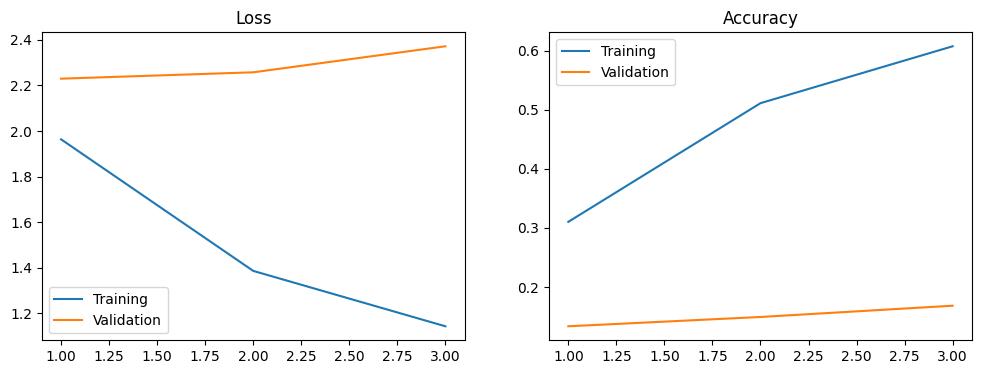

In [ ]:
# 손실함수, 정확도 그래프 그리기
def plot_loss_acc(history, epoch):

    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc, val_acc = history.history['accuracy'], history.history['val_accuracy']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(range(1, epoch + 1), loss, label='Training')
    axes[0].plot(range(1, epoch + 1), val_loss, label='Validation')
    axes[0].legend(loc='best')
    axes[0].set_title('Loss')

    axes[1].plot(range(1, epoch + 1), acc, label='Training')
    axes[1].plot(range(1, epoch + 1), val_acc, label='Validation')
    axes[1].legend(loc='best')
    axes[1].set_title('Accuracy')

    plt.show()

plot_loss_acc(history, 3)

**데이터 증강**
- 이미지 분류 문제에서 과대적합을 해소하고, 모델의 일반화된 Robust 한 성능을 확보하는 기법
- 이미지 데이터에 여러 가지 변형을 주어 훈련 데이터의 다양성을 확보하고 예측력 강화하는 기법

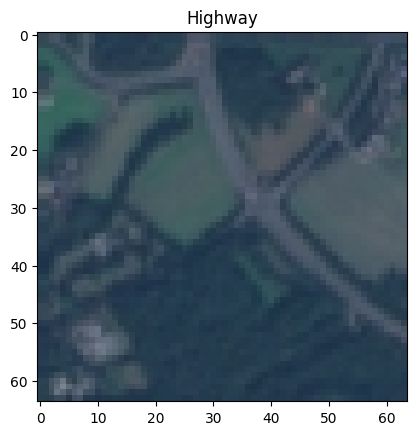

In [ ]:
# EuroSAT 데이터셋 중에서 하나의 샘플 이미지 시각화
# 샘플이미지
image_batch, label_batch = next(iter(train_data.take(1)))

image = image_batch[0]
label = label_batch[0].numpy()

plt.imshow(image)
plt.title(info.features["label"].int2str(label));

In [ ]:
# 데이터 증강 전후를 비교하는 시각화 함수를 정의
def plot_augmentation(original, augmented):

  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  axes[0].imshow(original)
  axes[0].set_title('Original')

  axes[1].imshow(augmented)
  axes[1].set_title('Augmented')

  plt.show()

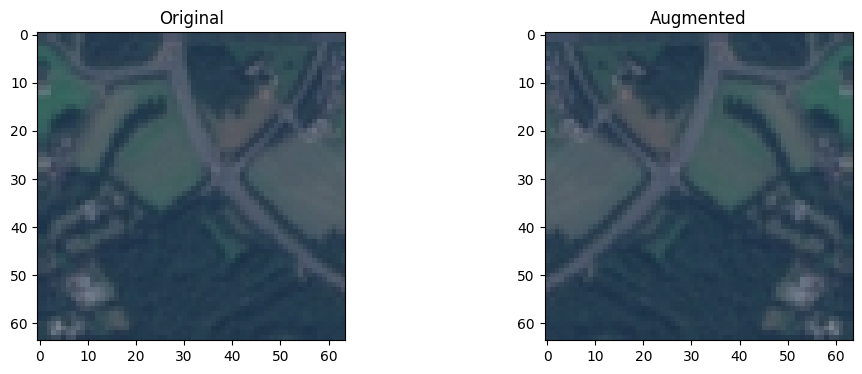

In [ ]:
# tf.image 모듈의 flip_left_right 함수 사용하여 이미지를 좌우 방향 뒤집음
# 좌우 뒤집기
lr_flip = tf.image.flip_left_right(image)
plot_augmentation(image, lr_flip)

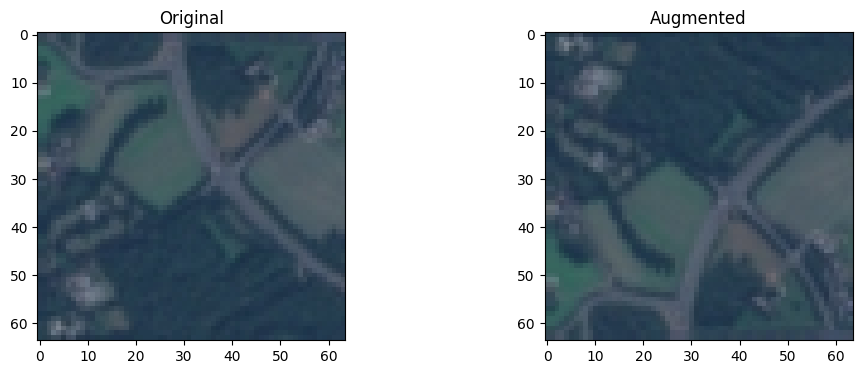

In [ ]:
# flip_up_down 함수 사용하여 이미지를 상하 방향으로 뒤집음
# 상하 뒤집기
ud_flip = tf.image.flip_up_down(image)
plot_augmentation(image, ud_flip)

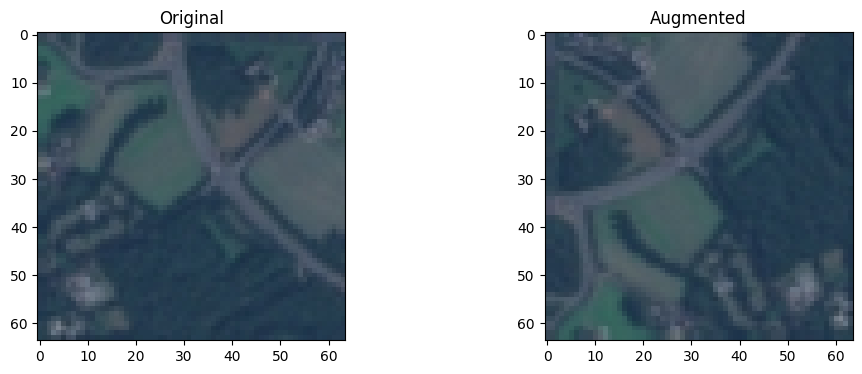

In [ ]:
# rot90 함수 사용하여 이미지를 반시계 방향으로 90도 회전
# 회전
rotate90 = tf.image.rot90(image)
plot_augmentation(image, rotate90)

- transpose 함수는 이미지 텐서 행렬의 행과 열의 위치를 바꿔줌

In [ ]:
# transpose
transpose = tf.image.transpose(image)

- central_crop 함수는 이미지의 중심에서 일정 부분을 잘라내는 방법 구현

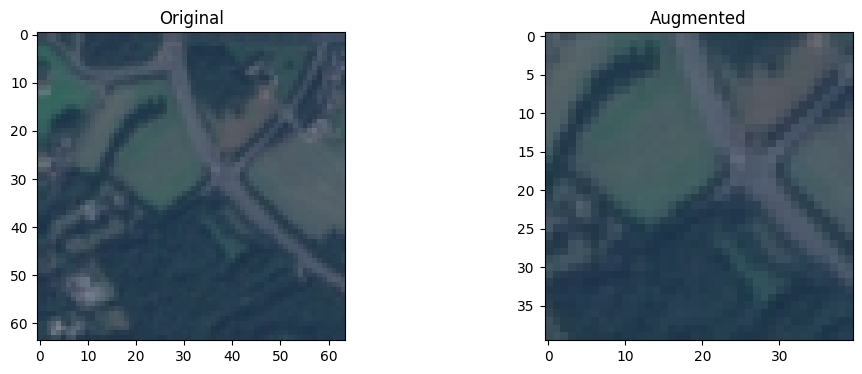

In [ ]:
# 이미지 자르기 1
crop1 = tf.image.central_crop(image, central_fraction=0.6)
plot_augmentation(image, crop1)

- resize_with_crop_or_pad 함수 사용하여 원본 이미지의 크기를 키움.
- random_crop 함수 사용</br> 이미지를 원본 크기와 같게 자르면 원본 이미지가 상하좌우 랜덤한 방향으로 이동

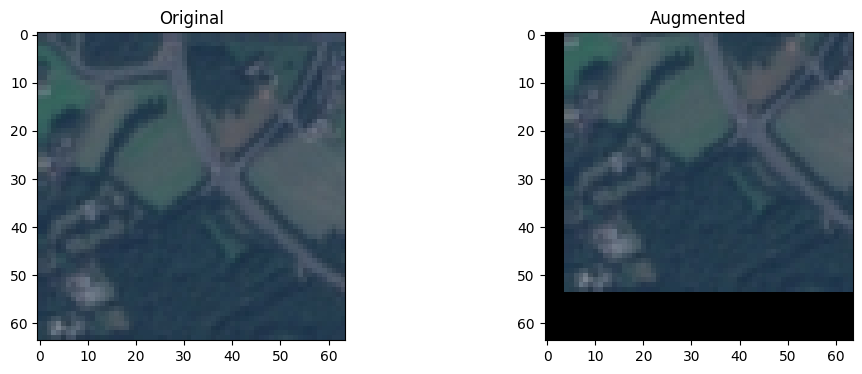

In [ ]:
# 이미지 자르기 2
img = tf.image.resize_with_crop_or_pad(image, 64+20, 64+20)  # 사이즈 키우기
crop2 = tf.image.random_crop(img, size=[64, 64, 3])
plot_augmentation(image, crop2)

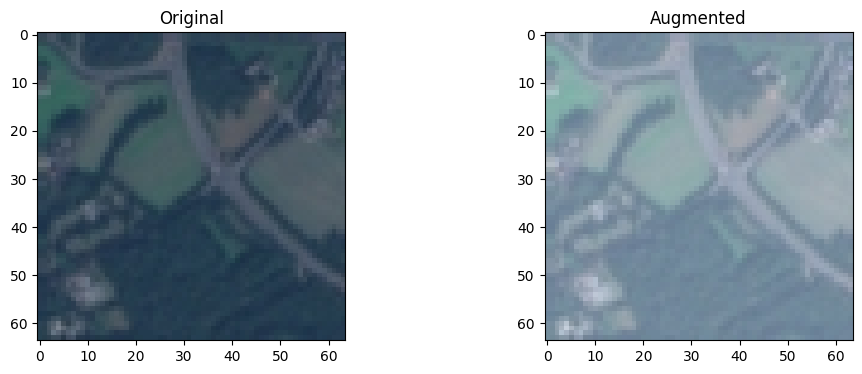

In [ ]:
# 이미지 밝기
brightness = tf.image.adjust_brightness(image, delta=0.3)
plot_augmentation(image, brightness)

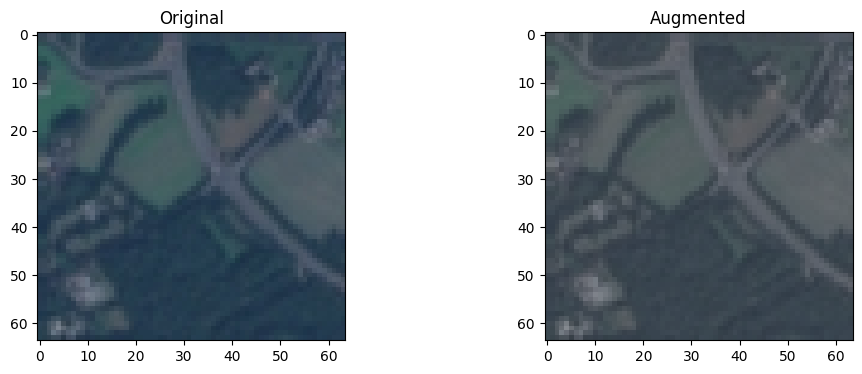

In [ ]:
# 이미지 채도
saturation = tf.image.adjust_saturation(image, saturation_factor=0.5)
plot_augmentation(image, saturation)

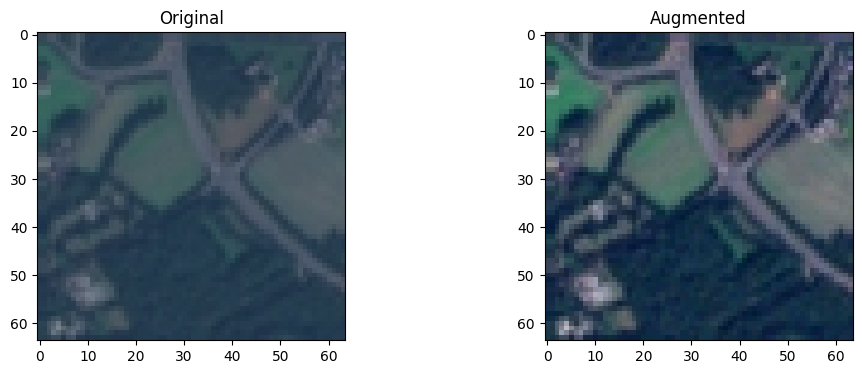

In [ ]:
# 이미지 대비
contrast = tf.image.adjust_contrast(image, contrast_factor=2)
plot_augmentation(image, contrast)

- 데이터 증강 및 전처리 수행하는 data_augmentation 함수 정의
- 이미지 증강 효과에 랜덤성 부여하기 위해 tf.image 모듈에서 지원하는 함수 중 'random_'으로 시작하는 함수 적용
- map 함수로 원본 데이터셋에 적용하고, shuffle 함수와 batch 함수 등을 적용하여 미니 배치로 만들기

In [ ]:
# 이미지 증강 전처리
def data_augmentation(image, label):

  image = tf.image.random_flip_left_right(image)  # 좌우 반전
  image = tf.image.random_flip_up_down(image)  # 상하 반전
  image = tf.image.random_brightness(image, max_delta=0.3)  # 밝기 변화
  image = tf.image.random_crop(image, size=[64, 64, 3])

  image = tf.cast(image, tf.float32) / 255.  # 0~1 정규화

  return image, label

train_aug = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
valid_aug = valid_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)

train_aug = train_aug.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
valid_aug = valid_aug.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print(train_aug)
print(valid_aug)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [ ]:
# 모델 생성
aug_model = build_model()

# 모델 컴파일
aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 훈련
aug_history = aug_model.fit(train_aug, validation_data=valid_aug, epochs = 3)

Epoch 1/3
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 246ms/step - accuracy: 0.1381 - loss: 3.0126 - val_accuracy: 0.1926 - val_loss: 2.2664
Epoch 2/3
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.3152 - loss: 1.8243 - val_accuracy: 0.2331 - val_loss: 2.2181
Epoch 3/3
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step - accuracy: 0.4137 - loss: 1.5907 - val_accuracy: 0.2226 - val_loss: 2.1517


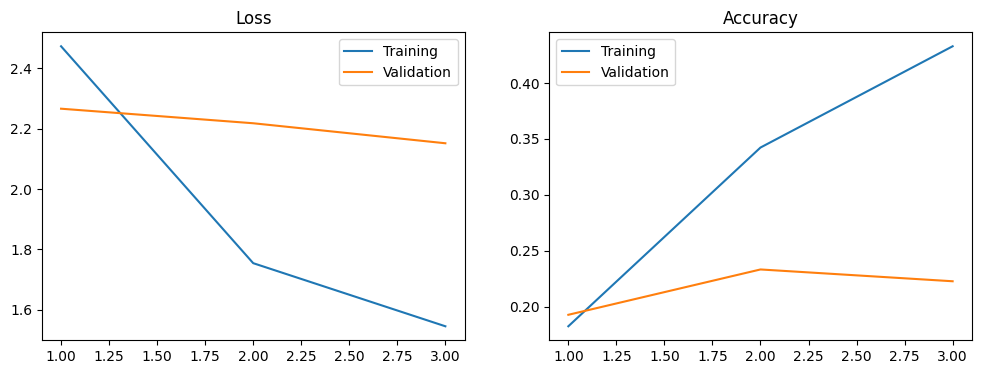

In [ ]:
# 손실함수, 정확도 그래프 그리기
plot_loss_acc(aug_history, 3)

-> 데이터 증강 전후 성능 자체는 큰 차이 없음

**ResNet 사전 학습 모델**
- 전이 학습
  - 방대한 이미지로 훈련 받은 딥러닝 모델 구조, 가중치를 그대로 가져옴.
  - 모델 끝단에 위치하는 Top 층에 위성 이미지를 분류할 수 있는 최종 분류기를 추가하는 방법

In [ ]:
# Pre-trained 모델을 사전 학습된 가중치와 함께 가져오기
from tensorflow.keras.applications import ResNet50V2

pre_trained_base = ResNet50V2(include_top=False, # top층 제거해줘야함, 여기에 최종 분류기를 대체해서 추가
                               weights='imagenet',
                               input_shape=[64, 64, 3])

# 사전 학습된 가중치를 업데이트 되지 않도록 설정
pre_trained_base.trainable = False

# 모델 구조 시각화
from tensorflow.keras.utils import plot_model
plot_model(pre_trained_base, show_shapes=True, show_layer_names=True, to_file='resnet50.png')

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.537852 to fit



최종적으로 10개의 클래스에 대한 다중 분류를 위해 softmax 함수 지정

In [ ]:
# Top 층에 Classifier 추가

def build_trainsfer_classifier():

  model = tf.keras.Sequential([

      # Pre-trained Base
      pre_trained_base,
      # Classifier 출력층
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
  ])

  return model

# 모델 구조
tc_model = build_trainsfer_classifier()
tc_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)              │ (None, 2, 2, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       1,048,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,622,410 (93.93 MB)

 Trainable params: 1,057,610 (4.03 MB)

 Non-trainable params: 23,564,800 (89.89 MB)